# SAXS FBP Reconstruction — First Test

Tests `smartt.saxs_fbp.saxs_fbp_reconstruction` on the frogbone dataset.

**Pipeline recap**: for each target q-direction `y` on the upper hemisphere,
`NearestNeighbor.get_sub_geometry` collapses the 8 azimuthal segments into a scalar
sinogram weighted by arc-fraction. We then apply a ramp filter and backproject with
ASTRA, recovering a scalar volume `F_y(x,y,z)` — the value of the voxel sphere
function at direction `y`.

In [1]:
try:
    from mumott.data_handling import DataContainer
except:
    !sh ../scripts/setup.sh
    !pip install --upgrade coverage pytest-cov

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


In [2]:
import sys
sys.path.insert(0, '/myhome/smartt')

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from mumott.data_handling import DataContainer

from smartt.saxs_fbp import (
    fibonacci_hemisphere,
    fbp_with_mumott_geometry,
    saxs_fbp_reconstruction,
    saxs_gd_reconstruction
)
import lovely_tensors as lt
lt.monkey_patch()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

device: cuda
GPU: NVIDIA A100 80GB PCIe


## 1. Load data

In [3]:
# Dataset split boundaries — set once here, used by all visualizations below.
# Single DataContainer:                    SPLIT_LOCATION = []
# combined_dc where first source has n1:   SPLIT_LOCATION = [n1]
# Three sources (n1, n2 in first two):     SPLIT_LOCATION = [n1, n1 + n2]
_DATASET_COLORS = ['darkorange', 'mediumseagreen', 'mediumpurple', 'firebrick', 'dodgerblue']
SPLIT_LOCATION = []


In [4]:
# DATA_PATH = '/myhome/data/smartt/shared/frogbone/dataset_qbin_0009.h5'
DATA_PATH        = '/myhome/data/smartt/shared/missing_wedge/full_data_zenodo/data/data_set_1.h5'
dc = DataContainer(DATA_PATH, nonfinite_replacement_value=0)
geometry = dc.geometry

print('dc.data shape     :', dc.data.shape,       '  (N, J, K, M)')
print('dc.weights shape  :', dc.weights.shape)
print('volume_shape      :', geometry.volume_shape)
print('projection_shape  :', geometry.projection_shape)
print('probed_coords     :', geometry.probed_coordinates.vector.shape, '  (N, M, I, 3)')
print('n_projections     :', len(dc.projections))

INFO:Inner axis found in dataset base directory. This will override the default.


INFO:Outer axis found in dataset base directory. This will override the default.
INFO:Rotation matrix generated from inner and outer angles, along with inner and outer rotation axis vectors. Rotation and tilt angles assumed to be in radians.
INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
dc.data shape     : (224, 65, 57, 8)   (N, J, K, M)
dc.weights shape  : (224, 65, 57, 8)
volume_shape      : [57 65 57]
projection_shape  : [65 57]
probed_coords     : (224, 8, 3, 3)   (N, M, I, 3)
n_projections     : 224


In [5]:
import h5py
import pickle
combined_dc = DataContainer('/myhome/data/smartt/shared/b411/dataset_b411R_inf_1_0.220_1.900.h5')
dc_remount = DataContainer('/myhome/data/smartt/shared/b411/dataset_b411R_inf1_remount_0.220_1.900.h5')
absorption_tomo_path = '/myhome/data/smartt/shared/b411/sirt_tomogram.h5'

SPLIT_LOCATION = [len(combined_dc.projections)]
## Load absorption and mask for dataset

with h5py.File(absorption_tomo_path, 'r') as file:
    sirt_recon = np.squeeze(np.array(file['/absorption_tomo']))
volume_shape_tomo = sirt_recon.shape
with open('/myhome/data/smartt/shared/b411/Otsu_mask_arrays.npy','rb') as fid:
# with open('/das/work/p21/p21438/20250304/OFFLINE/Combined_sample/Otsu_mask_arrays.npy','rb') as fid:
    mask = pickle.load(fid)
mask_shape = mask.shape
print(f'Absorption tomo shape: {volume_shape_tomo}')
print(f'Mask shape: {mask_shape}')

for proj in combined_dc.projections:
    proj.diode = np.pad(proj.diode, ((0,0),(27,28)), mode='constant', constant_values=1)
    proj.data = np.pad(proj.data, ((0,0),(27,28),(0,0)), mode='constant', constant_values=0)
    proj.weights = np.pad(proj.weights, ((0,0),(27,28),(0,0)), mode='constant', constant_values=0)

n = len(dc_remount.projections)
for i in range(n):
    dc_remount.projections[0].data *= 0.75 
    frame = dc_remount.projections[0]
    del dc_remount.projections[0]
    combined_dc.projections.append(frame)

    

# data_container_SAXS.geometry.read('/das/work/p21/p21438/20250304/OFFLINE/Combined_sample/combined_geometry.h5')
combined_dc.geometry.read('/myhome/data/smartt/shared/b411/combined_geometry.h5')
dc = combined_dc

INFO:Rotation matrices were loaded from the input file.
INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
INFO:Rotation matrices were loaded from the input file.
INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
Absorption tomo shape: (141, 111, 141)
Mask shape: (141, 111, 141)


In [6]:
dc.geometry.full_circle_covered = False

data  : min=0.000e+00  max=4.285e+05  mean=2.319e+04
weights: unique values [0. 1.]
valid pixels: 78.8%


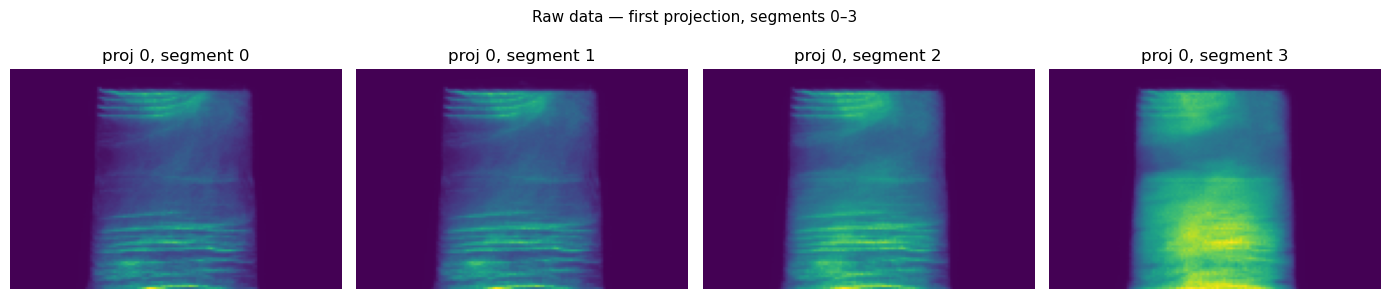

In [7]:
# Quick look at the data and weight ranges
print('data  : min={:.3e}  max={:.3e}  mean={:.3e}'.format(
    dc.data.min(), dc.data.max(), dc.data.mean()))
print('weights: unique values', np.unique(dc.weights)[:10])
print('valid pixels: {:.1f}%'.format(100 * (dc.weights > 0).mean()))

# One projection as a sanity check
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for s in range(4):
    axes[s].imshow(dc.data[0, :, :, s], aspect='auto')
    axes[s].set_title(f'proj 0, segment {s}')
    axes[s].axis('off')
plt.suptitle('Raw data — first projection, segments 0–3', fontsize=11)
plt.tight_layout()
plt.show()

## 2. Inspect q-direction grid

y_dirs shape: (30, 3)
y range: [0.017, 0.983]
all unit vectors: True


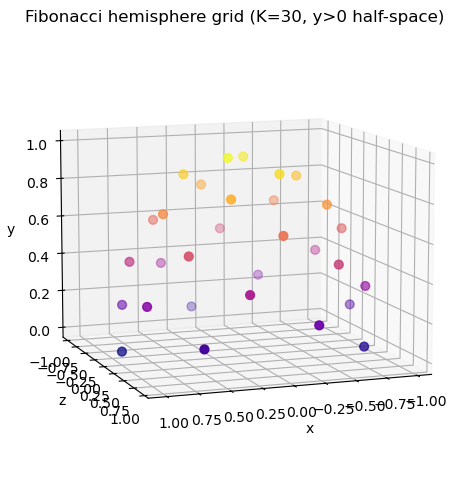

In [8]:
K = 30  # number of target q-directions (keep small for first test)
y_dirs = fibonacci_hemisphere(K, half_space='y')

print(f'y_dirs shape: {y_dirs.shape}')
print(f'y range: [{y_dirs[:, 1].min():.3f}, {y_dirs[:, 1].max():.3f}]')
print(f'all unit vectors: {np.allclose(np.linalg.norm(y_dirs, axis=-1), 1.0)}')

# Plot directions on the upper hemisphere (axes swapped: display as x, z, y)
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(y_dirs[:, 0], y_dirs[:, 2], y_dirs[:, 1], c=np.arange(K), cmap='plasma', s=40)
ax.set_xlabel('x'); ax.set_ylabel('z'); ax.set_zlabel('y')
ax.view_init(elev=10, azim=70)
ax.set_title(f'Fibonacci hemisphere grid (K={K}, y>0 half-space)')
plt.tight_layout()
plt.show()

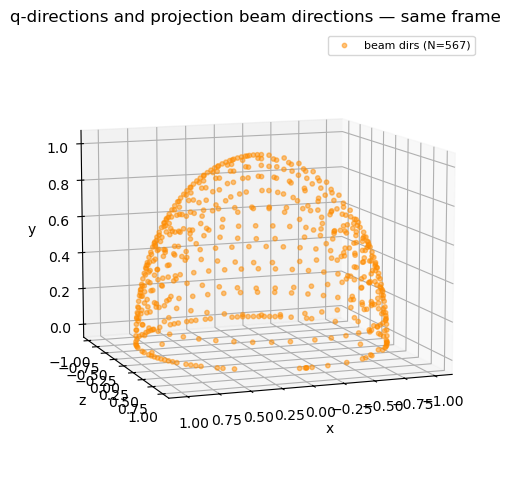

In [9]:
# Beam directions in sample frame (same frame as y_dirs) — PCA of probed q-arcs
_vecs = dc.geometry.probed_coordinates.vector        # (N, M, I, 3)
_qs   = _vecs.reshape(_vecs.shape[0], -1, 3)
_qs   = _qs / np.linalg.norm(_qs, axis=-1, keepdims=True).clip(1e-10)
_cov  = np.einsum('nij,nik->njk', _qs, _qs)
_, _ev = np.linalg.eigh(_cov)
_beam = _ev[:, :, 0]                                 # smallest eigenvec = beam normal
# Flip to y >= 0 to match y_dirs convention (y>0 half-space)
_beam[_beam[:, 1] < 0] *= -1

# Axes swapped: display as (x, z, y) so xz plane appears horizontal
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
# ax.scatter(y_dirs[:, 0], y_dirs[:, 2], y_dirs[:, 1],
#            c='steelblue', s=30, alpha=0.7, label=f'y_dirs (K={K})')
ax.scatter(_beam[:, 0], _beam[:, 2], _beam[:, 1],
           c='darkorange', s=10, alpha=0.5, label=f'beam dirs (N={len(_beam)})')
ax.set_xlabel('x'); ax.set_ylabel('z'); ax.set_zlabel('y')
ax.view_init(elev=10, azim=70)
ax.set_title('q-directions and projection beam directions — same frame')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [10]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=y_dirs[:, 0], y=y_dirs[:, 2], z=y_dirs[:, 1],
    mode='markers',
    marker=dict(size=4, color='steelblue', opacity=0.7),
    name=f'y_dirs (K={K})',
))

# Split beam directions by dataset using SPLIT_LOCATION
if not SPLIT_LOCATION:
    boundaries = [0, len(_beam)]
    labels = [f'beam dirs (N={len(_beam)})']
else:
    boundaries = [0] + list(SPLIT_LOCATION) + [len(_beam)]
    labels = [f'dataset {i + 1} (N={boundaries[i+1] - boundaries[i]})' for i in range(len(boundaries) - 1)]

for i, (start, end) in enumerate(zip(boundaries[:-1], boundaries[1:])):
    color = _DATASET_COLORS[i % len(_DATASET_COLORS)]
    seg = _beam[start:end]
    fig.add_trace(go.Scatter3d(
        x=seg[:, 0], y=seg[:, 2], z=seg[:, 1],
        mode='markers',
        marker=dict(size=2, color=color, opacity=0.5),
        name=labels[i],
    ))

fig.update_layout(
    scene=dict(xaxis_title='x', yaxis_title='z', zaxis_title='y'),
    title='q-directions and projection beam directions — same frame',
    width=700, height=550,
    legend=dict(font=dict(size=10)),
)
fig.show()


## 3. Inspect NearestNeighbor projection matrix

Before running the full reconstruction we build `NearestNeighbor` manually
to inspect the projection matrix and understand coverage.

In [11]:
# from mumott.methods.basis_sets import NearestNeighbor

# nn_mumott = NearestNeighbor(
#     directions=y_dirs,
#     probed_coordinates=dc.geometry.probed_coordinates,
#     enforce_friedel_symmetry=True,
#     integration_mode='simpson',
#     integration_tolerance=1e-8,
#     enforce_sparsity=False,
# )

# pm = nn_mumott.projection_matrix   # (N, M, K)
# print(f'projection_matrix shape: {pm.shape}  (N_proj, M_segments, K_dirs)')
# print(f'values > 0 per direction (min/mean/max): '
#       f'{(pm > 0).sum(axis=(0,1)).min()} / '
#       f'{(pm > 0).sum(axis=(0,1)).mean():.1f} / '
#       f'{(pm > 0).sum(axis=(0,1)).max()}')
# print('(= number of (proj, segment) pairs that contribute to each direction)')

In [12]:
# # How many projections contribute to each direction?
# # A projection contributes if any of its 8 segments has pm[n, :, k] > 0.
# n_contributing = np.array([
#     np.sum(np.any(pm[:, :, k] > 0, axis=1))
#     for k in range(K)
# ])

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# axes[0].bar(range(K), n_contributing)
# axes[0].set_xlabel('direction index k')
# axes[0].set_ylabel('# contributing projections')
# axes[0].set_title('Projections contributing to each q-direction')
# axes[0].axhline(n_contributing.mean(), color='r', linestyle='--', label=f'mean={n_contributing.mean():.0f}')
# axes[0].legend()

# # Weight distribution for direction k=0
# axes[1].hist(pm[pm[:, :, 0] > 0, 0], bins=20)
# axes[1].set_xlabel('arc-fraction weight')
# axes[1].set_ylabel('count')
# axes[1].set_title('Weight distribution for direction k=0\n(nonzero entries only)')

# plt.tight_layout()
# plt.show()

# print(f'\nContributing projections: min={n_contributing.min()}, '
#       f'mean={n_contributing.mean():.1f}, max={n_contributing.max()}')

## 4. Run FBP reconstruction

In [13]:
# Full reconstruction — uses the already-built nn internally (builds its own)
ball_threshold = 0.2
reconstruction, y_directions, nn = saxs_fbp_reconstruction(
    dc=dc,
    k_fibonacci=K,
    filter_type='hann',
    n_projection_samples=64,
    device=device,
    verbose=True,
    return_matrix=True,
    projection_method="ball",
    ball_threshold=ball_threshold,
    half_space='y',
)

# reconstruction, y_directions, nn = saxs_gd_reconstruction(
#     dc=dc,
#     k_fibonacci=K,
#     n_iterations=300,
#     lr=0.5,
#     n_projection_samples=64,
#     device=device,
#     verbose=True,
#     return_matrix=True,
#     projection_method="ball",
#     ball_threshold=ball_threshold,
#     half_space='y',
#     vol_init=reconstruction.clone().cpu().detach()
# )


print(f'\nreconstruction shape: {reconstruction.shape}  (K, X, Y, Z)')
print(f'value range: [{reconstruction.min():.3e}, {reconstruction.max():.3e}]')
print(f'finite values: {torch.isfinite(reconstruction).all().item()}')

INFO:Building projection matrix on GPU: K=30, n_samples=64, method=ball
INFO:Moving data to cuda...


SAXS FBP: 100%|██████████| 30/30 [00:01<00:00, 28.82dir/s, n_sub=158]



reconstruction shape: torch.Size([30, 141, 111, 141])  (K, X, Y, Z)
value range: [-1.043e+04, 9.250e+03]
finite values: True


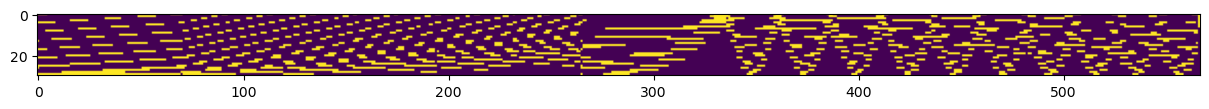

In [14]:
plt.figure(figsize=(15, 5))
adj_matrix_fbp = torch.from_numpy(nn.projection_matrix).sum(dim=1).T > 0
plt.imshow(adj_matrix_fbp) 
# plt.figure(figsize=(15, 5))
# adj_matrix_mummot = torch.from_numpy(pm).sum(dim=1).T > 0
# plt.imshow(adj_matrix_mummot) 

## 5. Visualise results

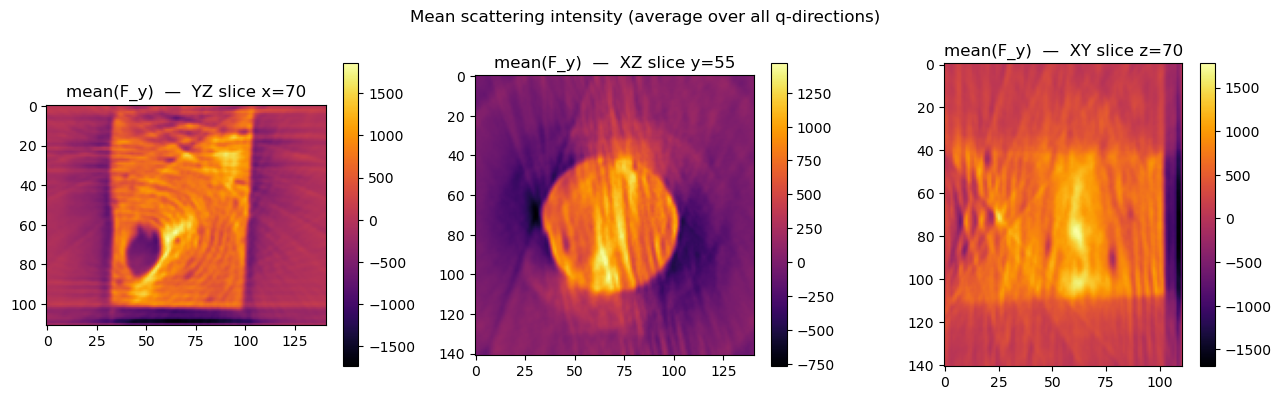

In [15]:
recon_np = reconstruction.cpu().numpy()   # (K, X, Y, Z)
X, Y, Z = recon_np.shape[1], recon_np.shape[2], recon_np.shape[3]
mid_x, mid_y, mid_z = X // 2, Y // 2, Z // 2

# --- Mean over all q-directions (should give mean scattering intensity) ---
mean_vol = recon_np.mean(axis=0)   # (X, Y, Z)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
im0 = axes[0].imshow(mean_vol[mid_x, :, :], cmap='inferno')
axes[0].set_title(f'mean(F_y)  —  YZ slice x={mid_x}')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(mean_vol[:, mid_y, :], cmap='inferno')
axes[1].set_title(f'mean(F_y)  —  XZ slice y={mid_y}')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(mean_vol[:, :, mid_z], cmap='inferno')
axes[2].set_title(f'mean(F_y)  —  XY slice z={mid_z}')
plt.colorbar(im2, ax=axes[2])

plt.suptitle('Mean scattering intensity (average over all q-directions)', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
import math
from matplotlib.gridspec import GridSpec

# Beam directions in the sample frame via PCA of the probed q-arcs.
# Each projection n has M*I q-direction vectors (probed_coordinates.vector).
# They all lie approximately in the plane ⊥ beam_n, so the eigenvector of the
# covariance matrix with the *smallest* eigenvalue is the beam direction.
_vecs = dc.geometry.probed_coordinates.vector          # (N, M, I, 3)
_qs   = _vecs.reshape(_vecs.shape[0], -1, 3)           # (N, M*I, 3)
_qs   = _qs / np.linalg.norm(_qs, axis=-1, keepdims=True).clip(1e-10)
_cov  = np.einsum('nij,nik->njk', _qs, _qs)           # (N, 3, 3)
_, _eigvecs = np.linalg.eigh(_cov)                     # columns sorted by ascending eigenvalue
proj_dirs   = _eigvecs[:, :, 0]                        # (N, 3) — smallest eigenvec = beam normal
# Flip to y >= 0 to match y_dirs convention (y>0 half-space)
proj_dirs[proj_dirs[:, 1] < 0] *= -1

# Exact adjacency: adj[n, k] = True if projection n contributes to direction k
adj = nn.projection_matrix.sum(axis=1) > 0            # (N, K) bool
print(f'proj_dirs shape : {proj_dirs.shape}  (N_projections, 3)')
print(f'adj shape       : {adj.shape}  (N_projections, K)')
print(f'mean contributing projections per direction: {adj.mean(axis=0).mean() * len(proj_dirs):.1f}')


def _hemisphere_ax(ax, y_dirs_arr, k_highlight, contributing=None):
    """Hemisphere context plot for direction k_highlight.

    Axes are swapped to (x, z, y) so the xz plane appears horizontal,
    matching the goniometer plotting convention.

    - Faint steelblue: all y-directions on the hemisphere.
    - Crimson point: highlighted direction y_dirs_arr[k_highlight].
    - Crimson curve: great circle {b : b · y_k = 0} in beam-direction space.
    - Darkorange solid/faint: projection beam directions, solid if contributing.
    """
    y_k = y_dirs_arr[k_highlight]

    def _s(d):
        # swap (x, y, z) → (x, z, y) for display
        return d[..., 0], d[..., 2], d[..., 1]

    # All y-directions (faint background)
    ax.scatter(*_s(y_dirs_arr), c='steelblue', s=10, alpha=0.15, depthshade=True)

    # Highlighted y-direction
    ax.scatter([y_k[0]], [y_k[2]], [y_k[1]], c='crimson', s=80, zorder=10)

    # Great circle orthogonal to y_k in beam-direction space
    perp = np.array([1.0, 0.0, 0.0]) if abs(y_k[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    u = np.cross(y_k, perp); u /= np.linalg.norm(u)
    v = np.cross(y_k, u)
    t = np.linspace(0, 2 * np.pi, 300)
    gc = np.outer(np.cos(t), u) + np.outer(np.sin(t), v)  # (300, 3)
    ax.plot(gc[:, 0], gc[:, 2], gc[:, 1], c='crimson', lw=1.2, alpha=0.7)

    # Projection beam directions: solid if they contribute, faint otherwise
    close = contributing if contributing is not None else np.ones(len(proj_dirs), dtype=bool)
    if close.any():
        ax.scatter(*_s(proj_dirs[close]), c='darkorange', s=14, alpha=0.85, depthshade=False)
    if (~close).any():
        ax.scatter(*_s(proj_dirs[~close]), c='darkorange', s=8, alpha=0.1, depthshade=False)

    ax.set_xlabel('x', fontsize=6); ax.set_ylabel('z', fontsize=6); ax.set_zlabel('y', fontsize=6)
    ax.tick_params(labelsize=5)
    ax.view_init(elev=10, azim=70)
    ax.set_title(f'k={k_highlight}', fontsize=7)

proj_dirs shape : (567, 3)  (N_projections, 3)
adj shape       : (567, 30)  (N_projections, K)
mean contributing projections per direction: 112.3


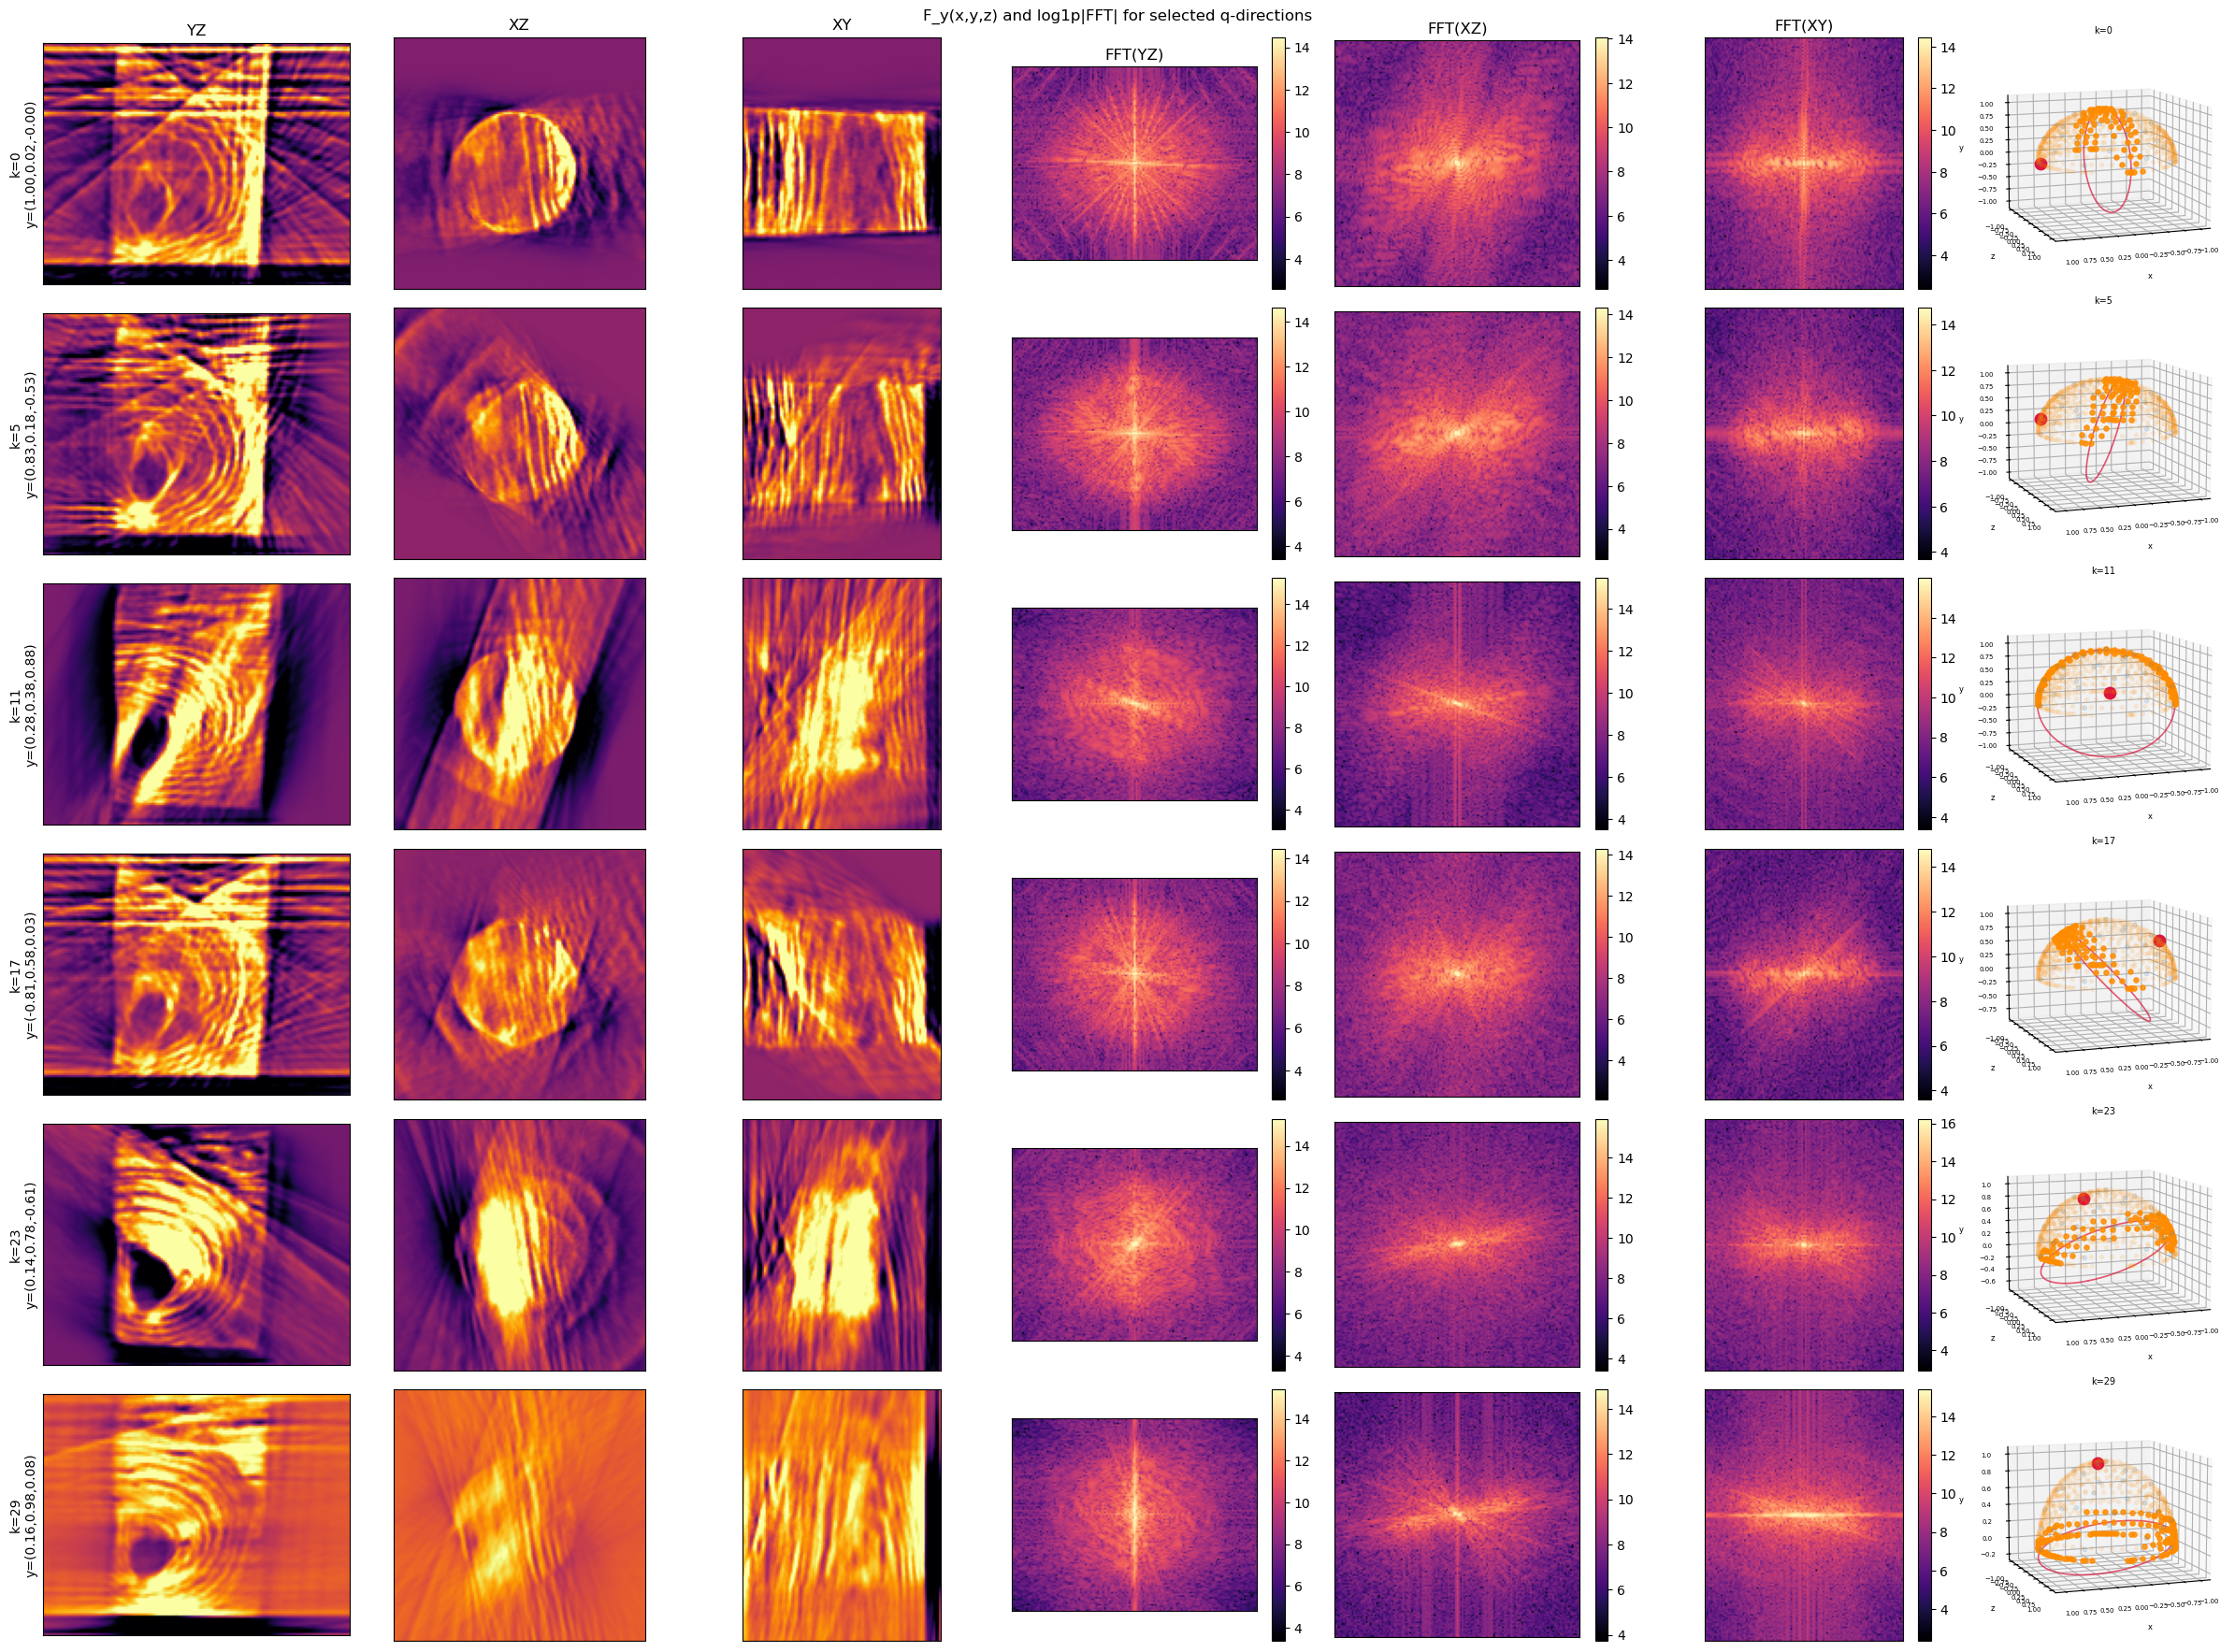

In [17]:
# --- Individual direction volumes for a few representative directions ---
n_show = min(6, K)
dir_indices = np.linspace(0, K - 1, n_show, dtype=int)

def log_fft2(sl):
    return np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(sl))))

fig = plt.figure(figsize=(24, 3 * n_show))
gs = GridSpec(n_show, 7, figure=fig, width_ratios=[1, 1, 1, 1, 1, 1, 0.8])

col_titles = ['YZ', 'XZ', 'XY', 'FFT(YZ)', 'FFT(XZ)', 'FFT(XY)']

for row, k in enumerate(dir_indices):
    vol_k = recon_np[k]   # (X, Y, Z)
    vmin, vmax = np.percentile(vol_k, [2, 98])
    # vmin = 0

    slices = [vol_k[mid_x, :, :], vol_k[:, mid_y, :], vol_k[:, :, mid_z]]
    fft_slices = [log_fft2(sl) for sl in slices]

    for col_idx, sl in enumerate(slices):
        ax = fig.add_subplot(gs[row, col_idx])
        ax.imshow(sl, cmap='inferno', vmin=vmin, vmax=vmax)
        if row == 0:
            ax.set_title(col_titles[col_idx])
        ax.set_xticks([]); ax.set_yticks([])
        if col_idx == 0:
            ax.set_ylabel(f'k={k}\ny=({y_directions[k, 0]:.2f},{y_directions[k, 1]:.2f},{y_directions[k, 2]:.2f})')

    for col_idx, fsl in enumerate(fft_slices):
        ax = fig.add_subplot(gs[row, col_idx + 3])
        im = ax.imshow(fsl, cmap='magma')
        if row == 0:
            ax.set_title(col_titles[col_idx + 3])
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax)

    ax_h = fig.add_subplot(gs[row, 6], projection='3d')
    _hemisphere_ax(ax_h, y_directions, k, contributing=adj[:, k])

plt.suptitle('F_y(x,y,z) and log1p|FFT| for selected q-directions', fontsize=12)
plt.tight_layout()
plt.show()

In [41]:
def hemisphere_plotly(y_dirs_arr, k_highlight, contributing=None, split_locations=None):
    """Interactive plotly hemisphere plot for direction k_highlight.

    Axes are swapped to (x, z, y) so the xz plane appears horizontal.

    split_locations: list of ints — boundaries between datasets in proj_dirs.
        []         → all beam dirs in one color.
        [240]      → first 240 in color 1, rest in color 2.
        [240, 400] → three groups with three colors, etc.
    """
    y_k = y_dirs_arr[k_highlight]

    # Great circle orthogonal to y_k
    perp = np.array([1.0, 0.0, 0.0]) if abs(y_k[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    u = np.cross(y_k, perp); u /= np.linalg.norm(u)
    v = np.cross(y_k, u)
    t = np.linspace(0, 2 * np.pi, 300)
    gc = np.outer(np.cos(t), u) + np.outer(np.sin(t), v)  # (300, 3)

    close = contributing if contributing is not None else np.ones(len(proj_dirs), dtype=bool)

    if not split_locations:
        boundaries = [0, len(proj_dirs)]
        labels = ['beam dirs']
    else:
        boundaries = [0] + list(split_locations) + [len(proj_dirs)]
        labels = [f'dataset {i + 1}' for i in range(len(boundaries) - 1)]

    traces = [
        go.Scatter3d(
            x=y_dirs_arr[:, 0], y=y_dirs_arr[:, 2], z=y_dirs_arr[:, 1],
            mode='markers',
            marker=dict(size=3, color='steelblue', opacity=0.15),
            name='all y-dirs',
        ),
        go.Scatter3d(
            x=[y_k[0]], y=[y_k[2]], z=[y_k[1]],
            mode='markers',
            marker=dict(size=8, color='crimson'),
            name=f'y_k (k={k_highlight})',
        ),
        go.Scatter3d(
            x=gc[:, 0], y=gc[:, 2], z=gc[:, 1],
            mode='lines',
            line=dict(color='crimson', width=2),
            name='great circle',
            opacity=0.7,
        ),
    ]

    for i, (start, end) in enumerate(zip(boundaries[:-1], boundaries[1:])):
        color = _DATASET_COLORS[i % len(_DATASET_COLORS)]
        label = labels[i]
        seg_dirs = proj_dirs[start:end]
        seg_close = close[start:end]

        if seg_close.any():
            traces.append(go.Scatter3d(
                x=seg_dirs[seg_close, 0], y=seg_dirs[seg_close, 2], z=seg_dirs[seg_close, 1],
                mode='markers',
                marker=dict(size=4, color=color, opacity=0.85),
                name=f'{label} (contributing)',
            ))
        if (~seg_close).any():
            traces.append(go.Scatter3d(
                x=seg_dirs[~seg_close, 0], y=seg_dirs[~seg_close, 2], z=seg_dirs[~seg_close, 1],
                mode='markers',
                marker=dict(size=3, color=color, opacity=0.1),
                name=f'{label} (other)',
            ))

    fig = go.Figure(traces)
    fig.update_layout(
        scene=dict(xaxis_title='x', yaxis_title='z', zaxis_title='y'),
        title=f'Hemisphere — k={k_highlight}  y=({y_k[0]:.2f}, {y_k[1]:.2f}, {y_k[2]:.2f})',
        width=650, height=550,
        legend=dict(font=dict(size=10)),
    )
    return fig

k = 0
hemisphere_plotly(y_directions, k, contributing=adj[:, k], split_locations=SPLIT_LOCATION).show()


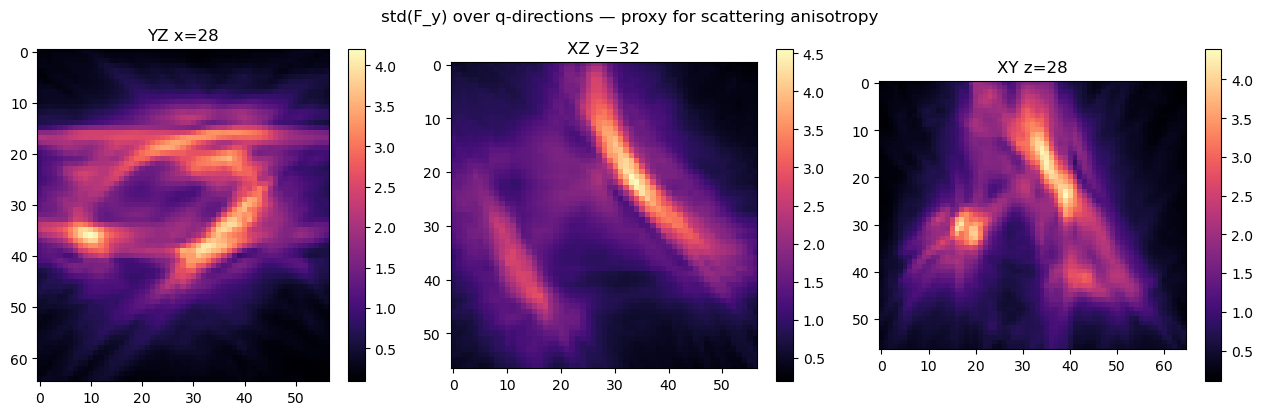

In [42]:
# --- Anisotropy: std over directions (where std is large the signal is anisotropic) ---
std_vol = recon_np.std(axis=0)   # (X, Y, Z)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (sl, title) in zip(axes, [
    (std_vol[mid_x, :, :], f'YZ x={mid_x}'),
    (std_vol[:, mid_y, :], f'XZ y={mid_y}'),
    (std_vol[:, :, mid_z], f'XY z={mid_z}'),
]):
    im = ax.imshow(sl, cmap='magma')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.suptitle('std(F_y) over q-directions — proxy for scattering anisotropy', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Single-direction deep-dive

Pick one direction and inspect the sub-sinogram going into FBP.

In [43]:
K_INSPECT = 0   # change to inspect other directions

sub_geometry, data_tuple = nn.get_sub_geometry(K_INSPECT, geometry, dc)
data_array, weight_array = data_tuple

N_sub = data_array.shape[0]
print(f'direction k={K_INSPECT}: y = {y_dirs[K_INSPECT].round(3)}')
print(f'contributing projections N_sub = {N_sub}')
print(f'sub-sinogram shape: {data_array.shape}  (N_sub, J, K_det)')
print(f'valid pixels: {(weight_array > 0).mean() * 100:.1f}%')
print(f'data range: [{data_array[weight_array > 0].min():.3e}, {data_array[weight_array > 0].max():.3e}]')

direction k=0: y = [ 1.     0.017 -0.   ]
contributing projections N_sub = 35
sub-sinogram shape: (35, 65, 57)  (N_sub, J, K_det)
valid pixels: 100.0%
data range: [0.000e+00, 2.502e+02]


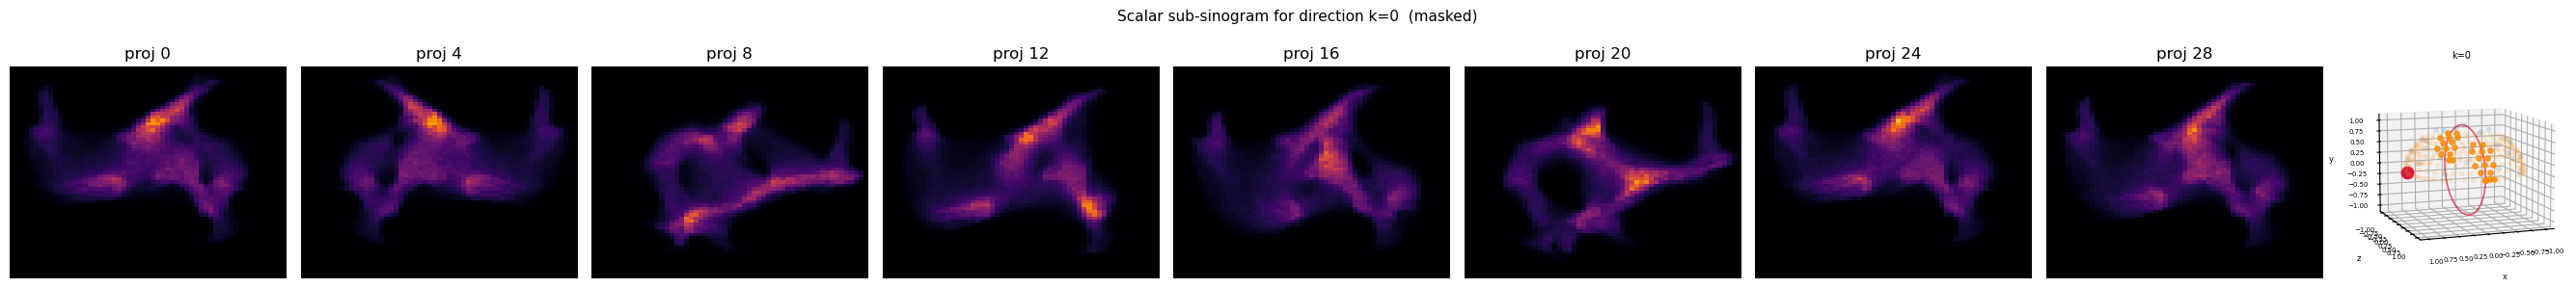

In [44]:
# Show a subset of the sub-sinogram projections
n_show_proj = min(8, N_sub)
proj_step = max(1, N_sub // n_show_proj)
selected = list(range(0, N_sub, proj_step))[:n_show_proj]

valid = (weight_array > 0).astype(data_array.dtype)
sino_masked = data_array * valid
vmin, vmax = sino_masked[valid > 0].min(), sino_masked[valid > 0].max()

fig = plt.figure(figsize=(3 * len(selected) + 3, 3))
gs = GridSpec(1, len(selected) + 1, figure=fig, width_ratios=[1] * len(selected) + [0.9])
axes = [fig.add_subplot(gs[0, i]) for i in range(len(selected))]
ax_h = fig.add_subplot(gs[0, -1], projection='3d')

for ax, n in zip(axes, selected):
    ax.imshow(sino_masked[n], cmap='inferno', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(f'proj {n}')
    ax.axis('off')

_hemisphere_ax(ax_h, y_directions, K_INSPECT, contributing=adj[:, K_INSPECT])

plt.suptitle(f'Scalar sub-sinogram for direction k={K_INSPECT}  (masked)', fontsize=11)
plt.tight_layout()
plt.show()

## 7. (Optional) Save reconstruction

In [45]:
import pathlib

OUT_DIR = pathlib.Path('/myhome/data/smartt/shared/results/saxs_fbp')
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = OUT_DIR / f'frogbone_fbp_K{K}.pt'
torch.save({'reconstruction': reconstruction.cpu(), 'y_directions': y_directions}, out_path)
print(f'saved → {out_path}')

saved → /myhome/data/smartt/shared/results/saxs_fbp/frogbone_fbp_K30.pt


## 8. Missing wedge mask validation

Validates the analytical missing-wedge mask from `smartt.saxs_isonet.wedge`.

- **Arc-length bar chart**: for each of the K q-directions, how many degrees of the
  great circle ⊥ y_k fall inside the unmeasurable polar caps.
- **Great-circle coverage** (`plot_wedge_hemisphere`): the great circle is coloured
  green (measured) / red (missing). Dashed orange circles mark the belt boundaries.
  Cross-check against the beam-direction dots from `hemisphere_plotly` above.
- **Fourier mask slices** (`plot_wedge_mask_slices`): three central cross-sections of
  the 3-D boolean mask in FFT-shifted coordinates (DC at centre). Green = measured,
  purple = missing.

**`ALPHA_DEG`** — half-angle (°) of the polar caps that the goniometer *cannot* reach.
Set it to match your acquisition geometry.

goniometer_axis : [0. 1. 0.]  (half_space='y')
alpha_deg       : 45.0°


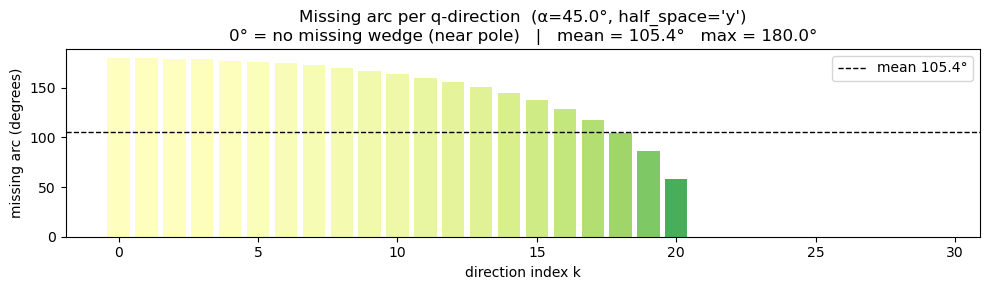


Per-direction summary:
  k= 0  y=(+1.00,+0.02,-0.00)  missing= 180.0° ←── equatorial (large wedge)
  k= 1  y=(-0.74,+0.05,+0.67)  missing= 179.7° ←── equatorial (large wedge)
  k= 2  y=(+0.09,+0.08,-0.99)  missing= 179.2° ←── equatorial (large wedge)
  k= 3  y=(+0.60,+0.12,+0.79)  missing= 178.4° ←── equatorial (large wedge)
  k= 4  y=(-0.97,+0.15,-0.17)  missing= 177.4° ←── equatorial (large wedge)
  k= 5  y=(+0.83,+0.18,-0.53)  missing= 176.0° ←── equatorial (large wedge)
  k= 6  y=(-0.25,+0.22,+0.94)  missing= 174.4° ←── equatorial (large wedge)
  k= 7  y=(-0.45,+0.25,-0.86)  missing= 172.4° ←── equatorial (large wedge)
  k= 8  y=(+0.90,+0.28,+0.33)  missing= 170.0° ←── equatorial (large wedge)
  k= 9  y=(-0.88,+0.32,+0.36)  missing= 167.2° ←── equatorial (large wedge)
  k=10  y=(+0.40,+0.35,-0.85)  missing= 164.0° ←── equatorial (large wedge)
  k=11  y=(+0.28,+0.38,+0.88)  missing= 160.2° ←── equatorial (large wedge)
  k=12  y=(-0.79,+0.42,-0.46)  missing= 155.7° ←── equatorial (l

In [46]:
from smartt.saxs_isonet.wedge import (
    goniometer_axis_for_half_space,
    missing_arc_length,
    all_missing_arcs,
    missing_wedge_mask_3d,
    plot_wedge_hemisphere,
    plot_wedge_mask_slices,
)

# ── Set these to match your acquisition ──────────────────────────────────────
ALPHA_DEG  = 45.0        # polar-cap half-angle (degrees from pole, NOT measurable)
HALF_SPACE = 'y'         # must match the half_space used in saxs_fbp/gd_reconstruction
# ─────────────────────────────────────────────────────────────────────────────

G_AXIS = goniometer_axis_for_half_space(HALF_SPACE)
print(f'goniometer_axis : {G_AXIS}  (half_space={HALF_SPACE!r})')
print(f'alpha_deg       : {ALPHA_DEG}°')

arcs = all_missing_arcs(y_directions, ALPHA_DEG, G_AXIS)   # (K,) radians
arcs_deg = np.degrees(arcs)

fig, ax = plt.subplots(figsize=(10, 3))
colors = plt.cm.RdYlGn_r(arcs / (2 * np.pi))
ax.bar(range(len(arcs_deg)), arcs_deg, color=colors)
ax.set_xlabel('direction index k')
ax.set_ylabel('missing arc (degrees)')
ax.set_title(f'Missing arc per q-direction  (α={ALPHA_DEG}°, half_space={HALF_SPACE!r})\n'
             f'0° = no missing wedge (near pole)   |   '
             f'mean = {arcs_deg.mean():.1f}°   max = {arcs_deg.max():.1f}°')
ax.axhline(arcs_deg.mean(), color='k', lw=1, ls='--', label=f'mean {arcs_deg.mean():.1f}°')
ax.legend()
plt.tight_layout()
plt.show()

print('\nPer-direction summary:')
for k, (y, arc) in enumerate(zip(y_directions, arcs_deg)):
    marker = ' ←── equatorial (large wedge)' if arc > 0.7 * arcs_deg.max() else ''
    marker = ' ←── pole (no wedge)' if arc < 1.0 else marker
    print(f'  k={k:2d}  y=({y[0]:+.2f},{y[1]:+.2f},{y[2]:+.2f})  missing={arc:6.1f}°{marker}')

In [47]:
# ── Great-circle coverage — cross-check against hemisphere_plotly ─────────────
# Green arc = beam directions in the measurable belt land here → data exists.
# Red arc   = polar-cap directions → missing wedge.
# Orange dashes = belt boundary (|b · goniometer_axis| = cos(alpha)).
#
# Validation: the contributing beam-direction dots from hemisphere_plotly above
# should cluster on the green segments.  Dots on the red segments would indicate
# a discrepancy between the analytical mask and the actual projection geometry.

K_SHOW = [0, K // 4, K // 2, K - 1]   # a spread from pole-ish to equatorial

for k in K_SHOW:
    fig = plot_wedge_hemisphere(
        rsm_dir=y_directions[k],
        alpha_deg=ALPHA_DEG,
        goniometer_axis=G_AXIS,
        title_extra=f'k={k}',
    )
    # Overlay contributing beam directions from the actual projection matrix
    c = adj[:, k]   # (N,) bool — True if projection n contributes to direction k
    fig.add_trace(__import__('plotly.graph_objects', fromlist=['Scatter3d']).Scatter3d(
        x=proj_dirs[c, 0], y=proj_dirs[c, 2], z=proj_dirs[c, 1],
        mode='markers',
        marker=dict(size=4, color='darkorange', opacity=0.8),
        name='contributing beam dirs',
    ))
    fig.add_trace(__import__('plotly.graph_objects', fromlist=['Scatter3d']).Scatter3d(
        x=proj_dirs[~c, 0], y=proj_dirs[~c, 2], z=proj_dirs[~c, 1],
        mode='markers',
        marker=dict(size=2, color='darkorange', opacity=0.1),
        name='non-contributing beam dirs',
        showlegend=False,
    ))
    fig.show()

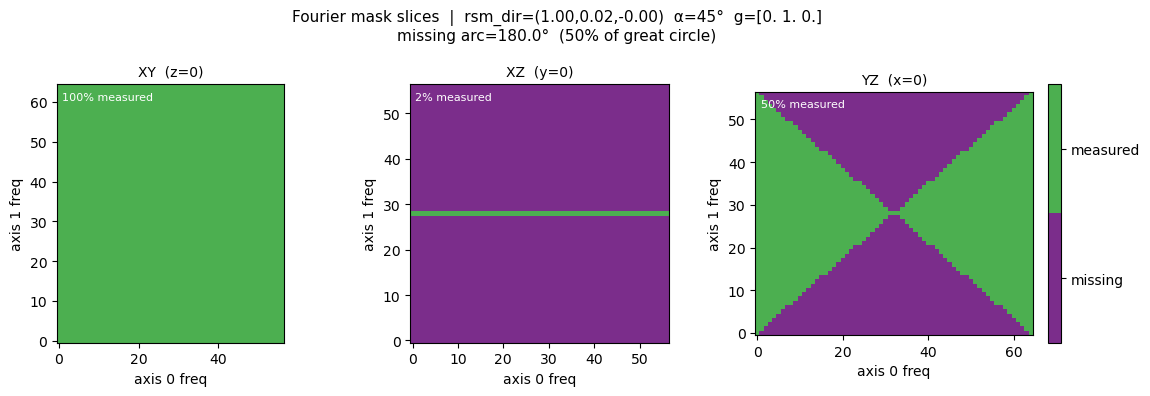

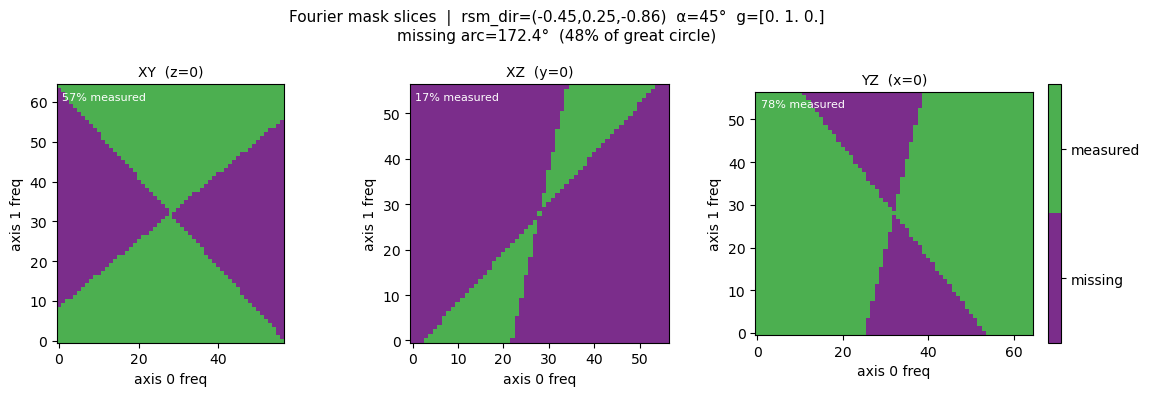

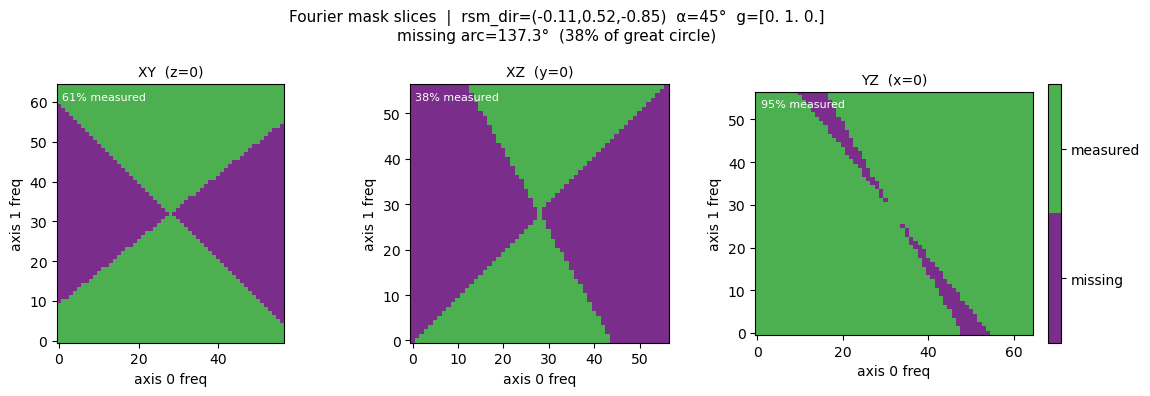

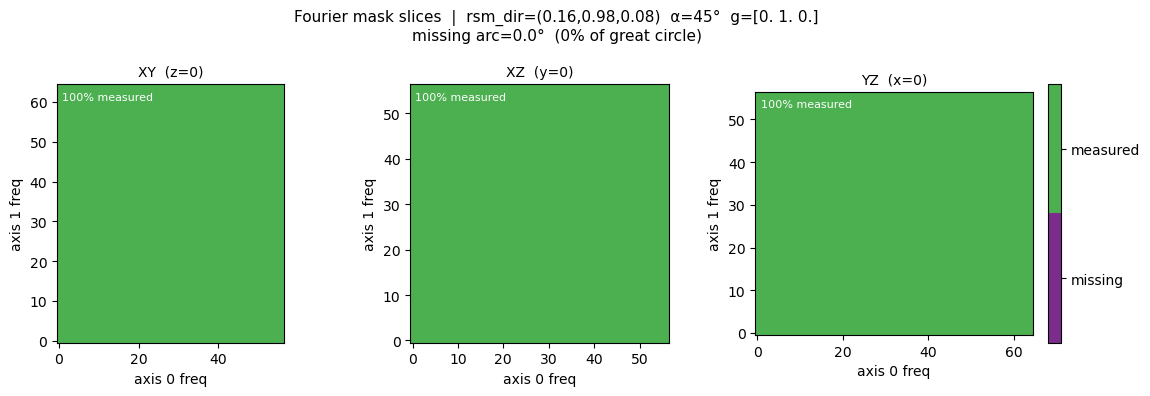

In [48]:
# ── Fourier mask slices ────────────────────────────────────────────────────────
# Three orthogonal central slices of the 3-D boolean mask (DC at centre).
# Green = measured frequencies, purple = missing.
#
# Expected pattern for half_space='y' (goniometer_axis=[0,1,0]):
#   - A direction near the Y pole (y[1] ≈ 1) → almost no missing region.
#   - A direction near the equator (y[1] ≈ 0) → a double-wedge gap around the
#     y_dir axis in the Fourier plane containing y_dir and goniometer_axis.

vol_shape = recon_np.shape[1:]   # (X, Y, Z) from actual reconstruction

for k in K_SHOW:
    fig = plot_wedge_mask_slices(
        rsm_dir=y_directions[k],
        alpha_deg=ALPHA_DEG,
        volume_shape=vol_shape,
        goniometer_axis=G_AXIS,
    )
    plt.show()

# Run isonet pipeline

In [49]:
from smartt.saxs_isonet.pipeline import run_pipeline
#python scripts/run_isonet.py     --data_path /myhome/data/smartt/shared/frogbone/dataset_qbin_0009.h5     --alpha_deg 45.0 --k_fibonacci=30 --recon_method='fbp' --output_dir='/myhome/data/smartt/shared/isonet_results/frogbone'

# run_pipeline(
#     reconstruction=reconstruction,   # (K, X, Y, Z) tensor
#     rsm_dirs=y_directions,             # (K, 3) array
#     alpha_deg=45.0,
#     half_space='y',
#     output_dir='/myhome/data/smartt/shared/isonet_results/frogbone',
#     num_rounds=1,
#     epochs_per_round=1,
#     batch_size=3
# )
